In [3]:
import pandas as pd

data = pd.read_csv("Loan_default.csv")
print(data.columns)

Index(['LoanID', 'Age', 'Income', 'LoanAmount', 'CreditScore',
       'MonthsEmployed', 'NumCreditLines', 'InterestRate', 'LoanTerm',
       'DTIRatio', 'Education', 'EmploymentType', 'MaritalStatus',
       'HasMortgage', 'HasDependents', 'LoanPurpose', 'HasCoSigner',
       'Default'],
      dtype='object')


In [5]:
print(data['Default'].value_counts())

Default
0    225694
1     29653
Name: count, dtype: int64


Confusion Matrix:
 [[25998 19141]
 [ 2451  3480]]

Classification Report:
               precision    recall  f1-score   support

           0       0.91      0.58      0.71     45139
           1       0.15      0.59      0.24      5931

    accuracy                           0.58     51070
   macro avg       0.53      0.58      0.48     51070
weighted avg       0.83      0.58      0.65     51070


AUC Score: 0.6162472179968095


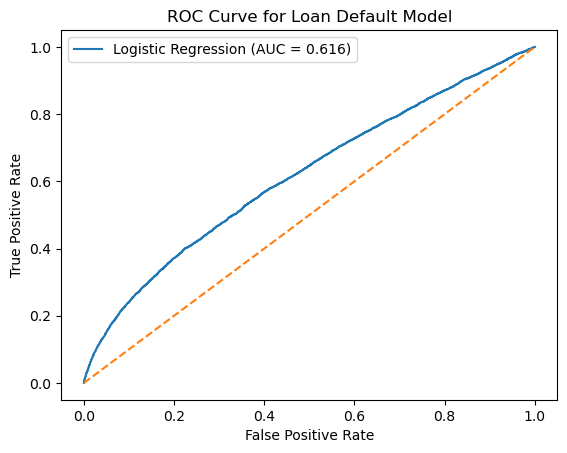

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_curve,
    roc_auc_score
)

# 1 Load dataset
data = pd.read_csv("Loan_default.csv")

# 2 Define features and target
X = data[['Income','LoanAmount','CreditScore']]
y = data['Default']

# 3 Train/Test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4 Weighted Logistic Regression (handles imbalance)
model = LogisticRegression(class_weight='balanced', max_iter=1000)

# 5 Train model
model.fit(X_train, y_train)

# 6 Predict probabilities
y_prob = model.predict_proba(X_test)[:,1]

# 7 Default threshold = 0.5
y_pred = (y_prob >= 0.5).astype(int)

# 8 Model evaluation
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9 ROC Curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# 10 AUC score
auc_score = roc_auc_score(y_test, y_prob)
print("\nAUC Score:", auc_score)

# 11 Plot ROC curve
plt.figure()

plt.plot(fpr, tpr, label="Logistic Regression (AUC = %.3f)" % auc_score)
plt.plot([0,1],[0,1],'--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Loan Default Model")

plt.legend()

plt.show()